# Effect of Learning Rate on Neural Network Training Stability

This notebook investigates how the learning rate affects neural network training behaviour.

A Multi-Layer Perceptron (MLP) classifier is trained several times using different learning rate values. The experiment compares training loss and validation accuracy in order to study convergence speed, optimisation stability and overall model performance.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [ ]:
np.random.seed(42)

## Step 1: Load the dataset

The digits dataset is used in this experiment. It contains small grayscale images of handwritten digits from 0 to 9.

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Class labels:", np.unique(y))

Feature matrix shape: (1797, 64)
Target vector shape: (1797,)
Class labels: [0 1 2 3 4 5 6 7 8 9]


## Step 2: Visualise sample images

The digits dataset contains 8 × 8 pixel images, so they appear blocky when enlarged. This is normal.

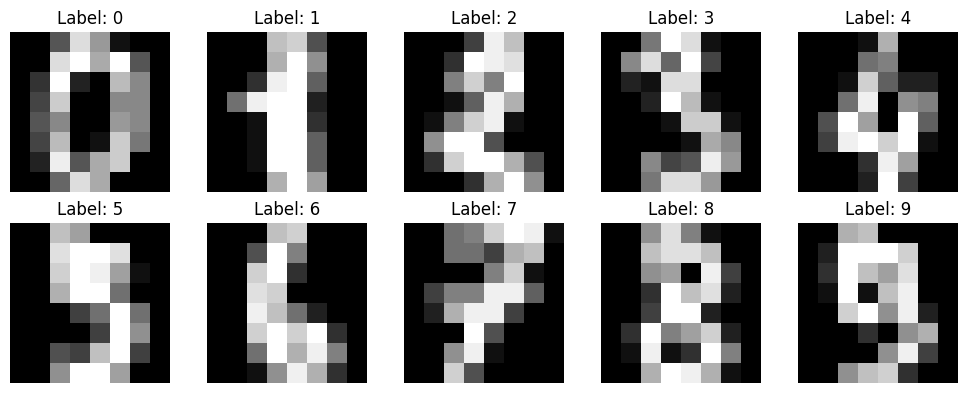

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 3: Split the dataset into training, validation and test sets

The data is first split into training and test sets. The training data is then split again to create a validation set.

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)
print("Test set:", X_test.shape)

Training set: (1149, 64)
Validation set: (288, 64)
Test set: (360, 64)


## Step 4: Standardise the features

Feature scaling is important because neural network training is sensitive to the scale of the input values.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

## Step 5: Define learning rate values and training settings

Several learning rate values are tested while keeping the neural network structure unchanged.

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
epochs = 30

loss_histories = {}
val_accuracy_histories = {}
trained_models = {}
summary_results = []

## Step 6: Train the neural network for each learning rate

The same Multi-Layer Perceptron architecture is trained repeatedly. Only the learning rate is changed.

The `warm_start=True` option allows the model to continue training for one epoch at a time, which helps us store the loss and validation accuracy after each epoch.

In [ ]:
for lr in learning_rates:
    print(f"Training model with learning rate = {lr}")

    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="sgd",
        learning_rate_init=lr,
        max_iter=1,
        warm_start=True,
        random_state=42
    )

    epoch_losses = []
    epoch_val_accuracies = []

    for epoch in range(epochs):
        mlp.fit(X_train_scaled, y_train)

        epoch_losses.append(mlp.loss_)

        y_valid_pred = mlp.predict(X_valid_scaled)
        val_acc = accuracy_score(y_valid, y_valid_pred)
        epoch_val_accuracies.append(val_acc)

    y_test_pred = mlp.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_test_pred)

    loss_histories[lr] = epoch_losses
    val_accuracy_histories[lr] = epoch_val_accuracies
    trained_models[lr] = mlp

    summary_results.append({
        "Learning Rate": lr,
        "Final Training Loss": epoch_losses[-1],
        "Best Validation Accuracy": max(epoch_val_accuracies),
        "Final Validation Accuracy": epoch_val_accuracies[-1],
        "Test Accuracy": test_acc
    })

Training model with learning rate = 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Training model with learning rate = 0.001


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Training model with learning rate = 0.01


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Training model with learning rate = 0.1


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

## Step 7: Create a summary table

The table below compares the final performance of the models trained with different learning rates.

In [ ]:
results_df = pd.DataFrame(summary_results)
results_df

,Learning Rate,Final Training Loss,Best Validation Accuracy,Final Validation Accuracy,Test Accuracy
0,0.0001,2.472648,0.079861,0.076389,0.066667
1,0.0010,1.970143,0.378472,0.378472,0.372222
2,0.0100,0.316528,0.920139,0.920139,0.927778
3,0.1000,0.014113,0.972222,0.972222,0.955556


## Step 8: Plot training loss curves

This figure shows how learning rate affects optimisation behaviour during training.

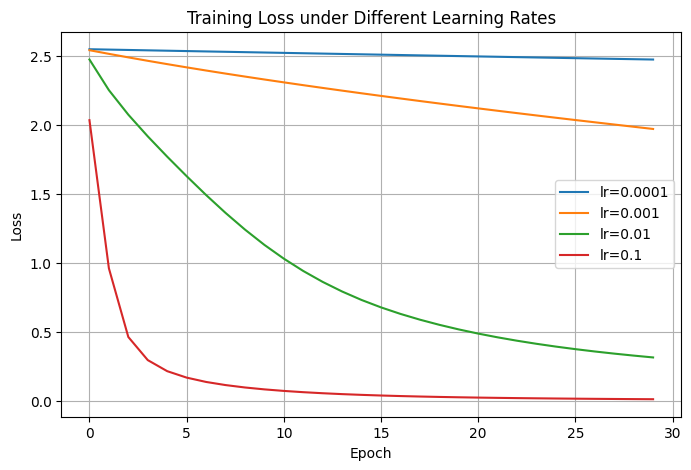

In [ ]:
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(loss_histories[lr], label=f"lr={lr}")

plt.title("Training Loss under Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("mlp_learning_rate_loss.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 9: Plot validation accuracy curves

This figure compares validation performance for different learning rate settings.

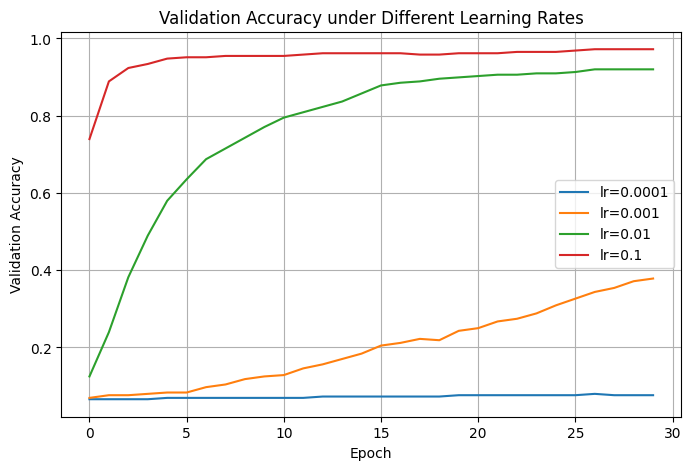

In [ ]:
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(val_accuracy_histories[lr], label=f"lr={lr}")

plt.title("Validation Accuracy under Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("mlp_learning_rate_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 10: Plot test accuracy as a bar chart

This figure gives a simple overall comparison of final predictive performance.

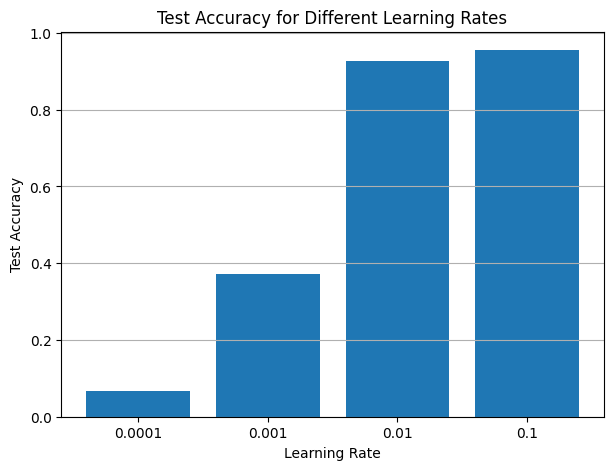

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(results_df["Learning Rate"].astype(str), results_df["Test Accuracy"])
plt.title("Test Accuracy for Different Learning Rates")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.grid(axis="y")
plt.savefig("mlp_learning_rate_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 11: Find the best learning rate

The best model is selected using validation accuracy because the aim is to find a value that generalises well to unseen data.

In [ ]:
best_row = results_df.loc[results_df["Best Validation Accuracy"].idxmax()]
best_row

,3
Learning Rate,0.100000
Final Training Loss,0.014113
Best Validation Accuracy,0.972222
Final Validation Accuracy,0.972222
Test Accuracy,0.955556


In [ ]:
print("Best learning rate:", best_row["Learning Rate"])
print("Best validation accuracy:", round(best_row["Best Validation Accuracy"], 4))
print("Test accuracy:", round(best_row["Test Accuracy"], 4))

Best learning rate: 0.1
Best validation accuracy: 0.9722
Test accuracy: 0.9556


## Step 12: Save the results table

This is useful if you want to include the performance table in your GitHub repository.

In [ ]:
results_df.to_csv("mlp_learning_rate_results.csv", index=False)
print("Saved: mlp_learning_rate_results.csv")

Saved: mlp_learning_rate_results.csv


## Discussion

The experiment shows that learning rate has a strong influence on neural network training stability.

Very small learning rates lead to slow but stable learning. Moderate learning rates usually produce faster convergence and stronger validation performance. Very large learning rates may cause unstable training because parameter updates become too large and the model struggles to converge smoothly.

These observations support the theoretical idea that learning rate controls the balance between convergence speed and optimisation stability.

## Accessibility Note

This notebook uses clear headings, labelled figures and step-by-step explanations. The saved plots can be inserted into the PDF tutorial with descriptive captions to support accessibility.

## Repository Link

GitHub Repository:  
https://github.com/venkateshparimi2709-sketch/learning-rate-training-stability